In [1]:
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.6/150.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 67.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

In [2]:
import pandas as pd
import numpy as np
import torch
import transformers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight
from tqdm.notebook import tqdm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
import os
import shap
from bertopic import BERTopic
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Read Data

In [5]:
os.chdir('/content/drive/My Drive/NLP-Letters-V2/notebooks/')
train_df = pd.read_csv('../data/combined_letters_degendered_with_topics_train_granular.csv')
val_df = pd.read_csv('../data/combined_letters_degendered_with_topics_val_granular.csv')
test_df = pd.read_csv('../data/combined_letters_degendered_with_topics_test_granular.csv')

In [6]:
train_df = train_df.drop('full_text', axis=1)
val_df = val_df.drop('full_text', axis=1)
test_df = test_df.drop('full_text', axis=1)

# Create Train and Test Set

In [7]:
topic_cols = [col for col in train_df.columns if col != 'label']

In [8]:
X_train = train_df[topic_cols]
y_train = train_df['label']

In [9]:
X_val = val_df[topic_cols]
y_val = val_df['label']

X_test = test_df[topic_cols]
y_test = test_df['label']

# Combine val + test into one eval set
X_eval = pd.concat([X_val, X_test], axis=0).reset_index(drop=True)
y_eval = pd.concat([y_val, y_test], axis=0).reset_index(drop=True)


# Train Model

In [32]:
# Step 5: Define hyperparameter grid
param_grid = {
    'n_estimators': [1000],
    'max_depth': [3, 5, 8, 10, 20],
    'class_weight': ['balanced'],
    'max_leaf_nodes': [3, 5, 7, 10]
}

# Step 6: Grid Search with internal cross-validation
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring='roc_auc',  # or 'roc_auc', 'accuracy'
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)



Fitting 5 folds for each of 4 candidates, totalling 20 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': ['balanced'],
                         'max_leaf_nodes': [3, 5, 7, 10],
                         'n_estimators': [1000]},
             scoring='roc_auc', verbose=2)

# Evaluate Model

In [33]:
# Step 7: Select best model
best_model = grid_search.best_estimator_
print("Best hyperparameters:", grid_search.best_params_)

# Step 8: Evaluate on combined val + test set
y_pred = best_model.predict(X_eval)

print("\nEvaluation Results on Combined Val+Test Set:")
print(classification_report(y_eval, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_eval, y_pred))

Best hyperparameters: {'class_weight': 'balanced', 'max_leaf_nodes': 3, 'n_estimators': 1000}

Evaluation Results on Combined Val+Test Set:
              precision    recall  f1-score   support

           0       0.35      0.43      0.39       780
           1       0.71      0.64      0.68      1737

    accuracy                           0.58      2517
   macro avg       0.53      0.54      0.53      2517
weighted avg       0.60      0.58      0.59      2517

Confusion Matrix:
 [[ 336  444]
 [ 625 1112]]


In [34]:
importances = grid_search.best_estimator_.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': topic_cols,
    'importance': importances
})

feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

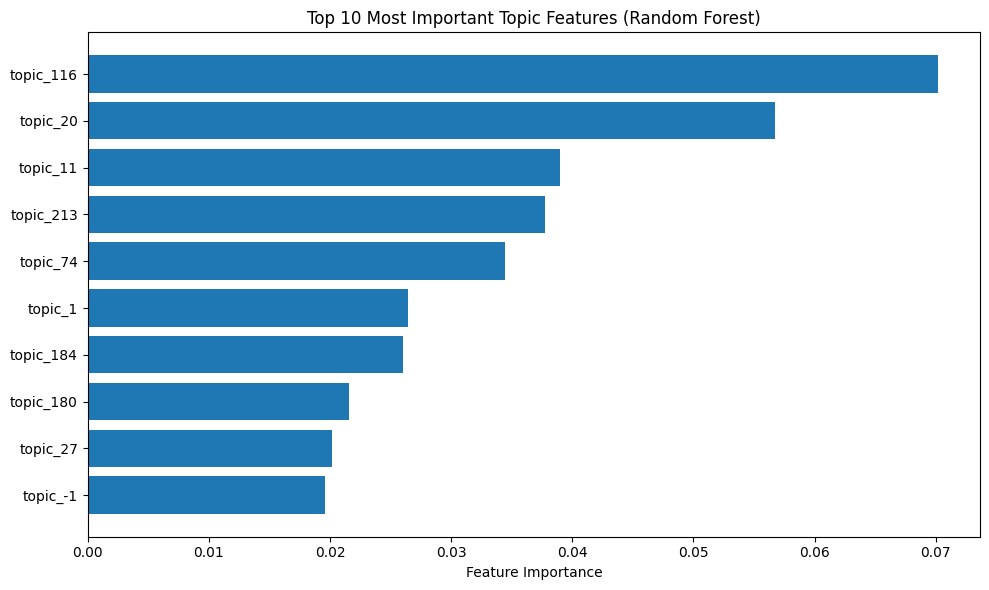

In [35]:
top_n = 10

plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance_df['feature'].iloc[:top_n][::-1],
    feature_importance_df['importance'].iloc[:top_n][::-1]
)
plt.xlabel("Feature Importance")
plt.title(f"Top {top_n} Most Important Topic Features (Random Forest)")
plt.tight_layout()
plt.show()

In [36]:
topic_model = BERTopic.load("../saved_models/topic_model_granular")

In [37]:

topic_info = topic_model.get_topic_info()

topic_number_to_name = dict(zip(topic_info['Topic'], topic_info['Name']))


In [38]:
def rename_topic_column(topic_col):
    if topic_col.startswith('topic_'):
        topic_num = int(topic_col.replace('topic_', ''))
        return topic_number_to_name.get(topic_num, topic_col)
    else:
        return topic_col

# SHAP

In [39]:
explainer = shap.TreeExplainer(best_model)

In [40]:
X_sample = X_eval.sample(1000, random_state=42)
X_sample = X_sample[topic_cols]
X_sample = X_sample.rename(columns=lambda x: rename_topic_column(x))

shap_values = explainer.shap_values(X_sample, check_additivity=False)

In [41]:
print("SHAP shape:", np.array(shap_values[1]).shape)
print("X_sample shape:", X_sample.shape)

SHAP shape: (231, 2)
X_sample shape: (1000, 231)


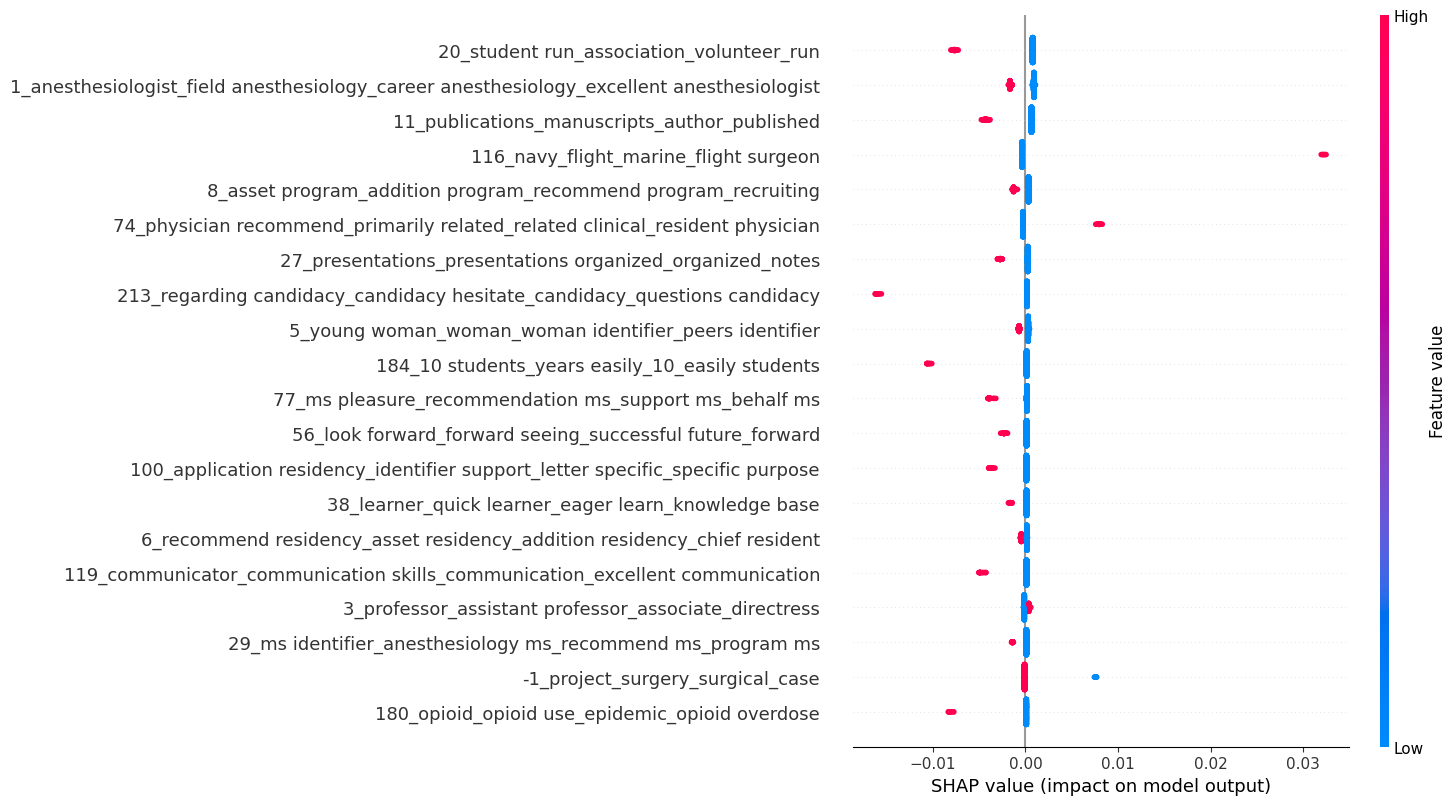

In [42]:
shap.summary_plot(shap_values[:, :, 1], X_sample)